In [42]:
#Day9_Hybrid_YOLO_HSV_Ball_Detector

In [43]:
!pip install -q ultralytics

In [44]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image as PILImage

In [112]:
def detect_ball_yolo(image_path,conf_threshold):
  print()
  results = model.predict(image_path, conf=conf_threshold, verbose=False)
  for box in results[0].boxes:
    if int(box.cls[0]) == 32:
      print("===================")
      print("YOLO detection used")
      print("===================")
      annotated = results[0].plot()
      plt.imshow(annotated)
      plt.axis('off')
      plt.show()
      #print("Class id :",int(box.cls[0]),"confidence : ",float(box.conf[0]))
      return float(box.conf[0])
  return None




def detect_ball(image_path, lower, upper):

 #load image
  img = cv2.imread(image_path)
  # convert to HSV
  hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)

  # create mask
  mask = cv2.inRange(hsv,lower,upper)

  # find contours
  contour_exter,hierarchy = cv2.findContours(
      mask,
      cv2.RETR_EXTERNAL,
      cv2.CHAIN_APPROX_SIMPLE
  )
  # filter by area + circularity
  best_ratio =0
  best_contour = None
  best_radius = None
  best_center = None
  for contour in contour_exter:
    area = cv2.contourArea(contour)
    if area > 100:
      center, radius = cv2.minEnclosingCircle(contour)
      circle_area = np.pi * radius**2
      ratio = area / circle_area
      if ratio > 0.7 and ratio > best_ratio:
        best_ratio = ratio
        best_contour = contour
        best_radius = radius
        best_center = center

  if best_center is None:
    print("HSV also failed to detect the ball")
    return None
  # print(best_ratio,best_radius)


  # draw result
  img_copy= img.copy()
  center_int = (int(best_center[0]),int(best_center[1]))
  radius_int = int(best_radius)
  cv2.circle(img_copy,center_int,radius_int,(0,255,0),4)

  # return or display the image
  plt.imshow(cv2.cvtColor(img_copy,cv2.COLOR_BGR2RGB))
  plt.show()
  return best_center, best_radius


def detect_ball_hybrid(image_path, conf_threshold=0.5):

  detection = detect_ball_yolo(image_path,conf_threshold)
  if detection is not None and detection>=conf_threshold:
    print("\n")
    print(f"Confidence of finding ball is : {detection}")
    return detection

  else:
    print("\n")
    print("============================================================")
    print("YOLO failed or low confidence — falling back to HSV detection")
    print("============================================================")
    lower_int = np.array([0, 0, 180])
    upper_int = np.array([179, 60, 255])
    detection_2 = detect_ball(image_path, lower_int, upper_int)
    if detection_2 is None:
      print("Both YOLO and HSV failed to detect the ball")
      return None
    print("\n")
    print(f"The best center and radius are : {detection_2}")
    return detection_2












YOLO failed or low confidence — falling back to HSV detection


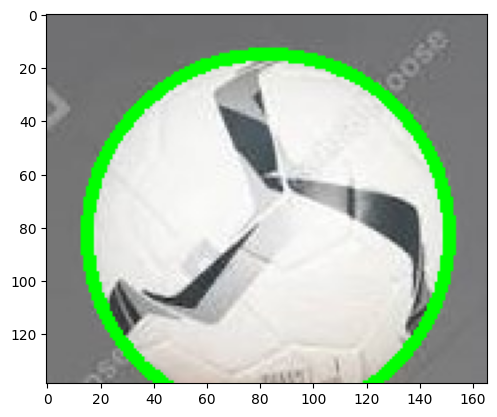



The best center and radius are : ((83.98623657226562, 83.14220428466797), 68.1305923461914)


In [117]:
# result_1 = detect_ball_hybrid("/content/sadio_ball.jpg")
result_2 = detect_ball_hybrid("/content/random_ball1.jpg")

In [ ]:
# Built a hybrid ball detector combining YOLOv8 (primary) with HSV color detection
#  (fallback) when YOLO's confidence is below threshold. Discovered a critical
#  edge case during testing: HSV can silently return a wrong detection
#   (matching background/clothing instead of the ball) rather than failing cleanly,
#    which is more dangerous than an outright failure since it produces
#    confident-looking bad data. Fixed by adding a circularity threshold (ratio > 0.7)
#    to reject non-ball-shaped contours, plus explicit None-checks at both the HSV and
#    hybrid levels so the system fails safely and reports "no detection" instead
#     of returning garbage coordinates.